# Part 7 — Controls

Three independent controls confirm that cross-mouse representational
consistency is not an artifact of (1) trial-history adaptation within a
session, (2) correlated pupil-area fluctuations across mice, or (3)
correlated running-speed fluctuations across mice.

Control 1 (adaptation): per-image consistency is computed separately from
the chronologically first and second halves of trials; if adaptation drives
consistency rather than genuine image representation, the two halves should
disagree. Control 2 & 3 (behavioral state): per-image pupil-area CV and
running-speed CV across mice are compared to per-image consistency; shared
arousal states across mice would inflate both CV and consistency together.

**Depends on:** `responses.h5` (VISp trial-level datasets),
               `behavioral_state.parquet`, `part1_outputs.npz`,
               `manifest.json`
**Outputs saved:** none (terminal notebook)

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path(".").resolve()))
from utils import (
    setup_archive,
    window_response,
    compute_similarity_matrices,
    per_image_consistency,
    cluster_bootstrap_ci,
    apply_plot_style,
    ts_ratio,
    print_figure_data,
)

import json
import gc
from itertools import combinations
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import spearmanr, pearsonr, ttest_1samp

SEED = 42
rng  = np.random.default_rng(SEED)

plt.rcParams.update({
    'font.family': 'sans-serif', 'font.size': 11,
    'axes.labelsize': 12, 'axes.titlesize': 12,
    'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'legend.fontsize': 9.5, 'figure.dpi': 150,
})
sns.set_style('ticks')

colors   = apply_plot_style()
COL_DATA = colors["COL_DATA"]   # default scatter/histogram color — no real category in this notebook
COL_FIT  = colors["COL_FIT"]    # annotations / statistics
COL_REF  = colors["COL_REF"]    # reference lines / baselines

In [2]:
# Load archive, extract if needed, resolve output paths.
manifest, bin_edges, ARCHIVE_DIR, FIGURES_DIR, OUTPUTS_DIR = setup_archive(
    zip_path    = '../preprocessed_data.zip',
    archive_dir = '../preprocessed_data',
    figures_dir = '../figures',
    outputs_dir = '.',
)
N_IMAGES    = manifest['n_images']
SESSION_IDS = manifest['selected_session_ids_visp']

p1 = np.load(OUTPUTS_DIR / 'part1_outputs.npz')
consistency_per_image = p1['consistency']          # (118,)
noise_ceiling         = p1['noise_ceiling']        # (32, 118)
mean_nc               = noise_ceiling.mean(0)      # (118,)
print(f'Part 1 consistency loaded: {len(consistency_per_image)} images')

df_state = pd.read_parquet(ARCHIVE_DIR / 'behavioral_state.parquet')
print(f'Behavioral state: {len(df_state):,} rows, '
      f'{df_state.session_id.nunique()} sessions')

Archive already extracted: C:\Users\janak\GitHub\cross-mouse-v1-rsa\preprocessed_data
Manifest: 32 VISp sessions | 118 images | 479 bins × 1 ms
Part 1 consistency loaded: 118 images
Behavioral state: 188,763 rows, 32 sessions


## 7.1 — Adaptation control: early vs. late trial consistency

For each session the trial set is divided at the chronological midpoint
into an early half and a late half. Cross-mouse consistency is computed
independently from each half using the same RSA pipeline as Part 1. If
neural adaptation to repeated stimuli were driving consistency (rather than
genuine image tuning), the two halves would disagree: later trials would
produce higher or lower consistency in a systematic, image-idiosyncratic
pattern. No such disagrement is expected if the signal is stable.

Data loaded: VISp trial-level table (`trial_level_0_250ms`, `trial_frame`,
`trial_start_time`) from `responses.h5`.

In [3]:
def zscore_columns(X):
    """Z-score each column (unit) of a (n_images, n_units) matrix."""
    return (X - X.mean(0)) / (X.std(0) + 1e-8)


def half_response_matrices(trial_counts, trial_frames, trial_times):
    """
    Split trials chronologically (per image) into early and late halves,
    return mean z-scored response matrices for each half.
    """
    n_units = trial_counts.shape[1]
    early_X = np.zeros((N_IMAGES, n_units), dtype=np.float32)
    late_X  = np.zeros((N_IMAGES, n_units), dtype=np.float32)

    for img_id in range(N_IMAGES):
        mask = trial_frames == img_id
        if mask.sum() < 4:
            continue
        counts = trial_counts[mask]
        times  = trial_times[mask]
        order  = np.argsort(times)
        half   = len(order) // 2
        early_X[img_id] = counts[order[:half]].mean(0)
        late_X[img_id]  = counts[order[half:]].mean(0)

    return zscore_columns(early_X), zscore_columns(late_X)

In [4]:
print('Loading trial-level tables from responses.h5...')
early_mats = []
late_mats  = []

with h5py.File(ARCHIVE_DIR / 'responses.h5', 'r') as f:
    for sid in SESSION_IDS:
        grp    = f[f'natural_scenes/VISp/{sid}']
        counts = grp['trial_level_0_250ms'][:]   # (n_trials, n_units)
        frames = grp['trial_frame'][:]            # (n_trials,)
        times  = grp['trial_start_time'][:]       # (n_trials,)

        early_X, late_X = half_response_matrices(counts, frames, times)
        early_mats.append(early_X.astype(np.float32))
        late_mats.append(late_X.astype(np.float32))

        del counts, frames, times, early_X, late_X
        gc.collect()

print(f'Loaded {len(early_mats)} sessions.')

# Compute per-image consistency for each half
early_sims = compute_similarity_matrices(early_mats)
late_sims  = compute_similarity_matrices(late_mats)

c_early, _, _ = per_image_consistency(early_sims)
c_late,  _, _ = per_image_consistency(late_sims)

# Per-image difference
delta_c = c_early - c_late

r_adapt, p_adapt = spearmanr(c_early, c_late)
t_stat, p_delta  = ttest_1samp(delta_c, 0.0)

print(f'\nEarly vs. late consistency:')
print(f'  Spearman r across images: {r_adapt:.3f}  (p = {p_adapt:.2e})')
print(f'  Mean early: {c_early.mean():.4f}  ±  {c_early.std():.4f}')
print(f'  Mean late:  {c_late.mean():.4f}  ±  {c_late.std():.4f}')
print(f'  Mean Δ (early − late): {delta_c.mean():.5f}  (t-test p = {p_delta:.3f})')

Loading trial-level tables from responses.h5...


Loaded 32 sessions.

Early vs. late consistency:
  Spearman r across images: 0.960  (p = 6.05e-66)
  Mean early: 0.2747  ±  0.1053
  Mean late:  0.2594  ±  0.0958
  Mean Δ (early − late): 0.01530  (t-test p = 0.000)


## 7.2 — Pupil-area control

If mice share transient arousal fluctuations time-locked to image onset, and
arousal modulates V1 gain, images that evoke high arousal in all mice would
show elevated responses—and therefore elevated cross-mouse consistency—purely
through shared state rather than shared tuning. The coefficient of variation
(CV = σ/μ) of pupil area across the 32 sessions per image captures how much
between-mouse pupil diversity differs by image. A positive correlation between
per-image pupil CV and per-image consistency would implicate shared state; the
null hypothesis (no correlation) supports the tuning interpretation.

In [5]:
# Six sessions lack eye tracking; compute CV on the remaining sessions only
eye_sessions = set(df_state['session_id'].unique()) - {
    732592105, 715093703, 719161530, 721123822, 737581020, 739448407
}

df_pupil = df_state[df_state['session_id'].isin(eye_sessions)].copy()
df_pupil = df_pupil.dropna(subset=['pupil_area'])

pupil_stats = df_pupil.groupby('image_id')['pupil_area'].agg(
    pupil_mean='mean',
    pupil_std='std',
).reset_index()
pupil_stats['pupil_cv'] = (
    pupil_stats['pupil_std'] / (pupil_stats['pupil_mean'].abs() + 1e-8)
)

# Align to image order 0–117
pupil_cv = np.array([
    pupil_stats.loc[pupil_stats['image_id'] == i, 'pupil_cv'].values[0]
    if i in pupil_stats['image_id'].values else np.nan
    for i in range(N_IMAGES)
])
valid_p   = ~np.isnan(pupil_cv)
r_pupil, p_pupil = spearmanr(pupil_cv[valid_p], consistency_per_image[valid_p])

print(f'\nPupil-area CV vs. consistency:')
print(f'  n images (with eye tracking): {valid_p.sum()}')
print(f'  Spearman r = {r_pupil:.3f}  (p = {p_pupil:.3f})')
print(f'  Interpretation: {"no significant relationship" if p_pupil > 0.05 else "significant — flag"}')


Pupil-area CV vs. consistency:


  n images (with eye tracking): 118
  Spearman r = 0.056  (p = 0.548)
  Interpretation: no significant relationship


## 7.3 — Running-speed control

Running-speed modulates V1 gain (Niell & Stryker, 2010). If images that evoke
more running across mice also systematically drive stronger or more consistent
V1 responses, running-CV could inflate consistency estimates. The per-image
running-CV is the coefficient of variation of mean running speed across mice
for each image. As with the pupil analysis, a non-significant correlation
with per-image consistency is the expected null result.

In [6]:
run_stats = df_state.groupby('image_id')['running_speed'].agg(
    run_mean='mean',
    run_std='std',
).reset_index()
run_stats['run_cv'] = (
    run_stats['run_std'] / (run_stats['run_mean'].abs() + 1e-8)
)

run_cv = np.array([
    run_stats.loc[run_stats['image_id'] == i, 'run_cv'].values[0]
    if i in run_stats['image_id'].values else np.nan
    for i in range(N_IMAGES)
])
valid_r  = ~np.isnan(run_cv)
r_run, p_run = spearmanr(run_cv[valid_r], consistency_per_image[valid_r])

print(f'\nRunning-speed CV vs. consistency:')
print(f'  n images: {valid_r.sum()}')
print(f'  Spearman r = {r_run:.3f}  (p = {p_run:.3f})')


Running-speed CV vs. consistency:
  n images: 118
  Spearman r = -0.033  (p = 0.725)


---
## Figures

**Fig. 7** — Three controls show that cross-mouse consistency is not an
artifact of adaptation, pupil-area fluctuations, or running-speed fluctuations.

**S10** — Adaptation difference distribution and both-halves comparison.


Fig. 7A — Adaptation control: early vs. late trial consistency per image

--- consistency_early_half ---
shape=(118,)
[0.374009 0.140579 0.261737 0.368076 0.409528 0.32051  0.375335 0.122165 0.216978 0.188181 0.233129 0.207071 0.265008 0.25242  0.226296 0.336903 0.33582  0.395129 0.296116 0.338711]
...[118 elements total]

--- consistency_late_half ---
shape=(118,)
[0.335189 0.117298 0.259429 0.349642 0.445021 0.315044 0.338655 0.124253 0.2358   0.148546 0.210214 0.198517 0.212835 0.259497 0.231746 0.331041 0.319387 0.388192 0.263786 0.287194]
...[118 elements total]

--- spearman_r_early_vs_late ---
0.9599589509858703

--- spearman_p_early_vs_late ---
6.051319115913142e-66

Fig. 7B — Pupil-area control: pupil-area CV vs. cross-mouse consistency

--- pupil_cv_valid_images ---
shape=(118,)
[0.668442 0.651176 0.666233 0.683628 0.66237  0.668473 0.617176 0.65754  0.666034 0.648711 0.660413 0.667441 0.647697 0.67411  0.665784 0.669688 0.651371 0.662301 0.648009 0.632007]
...[118 elements 

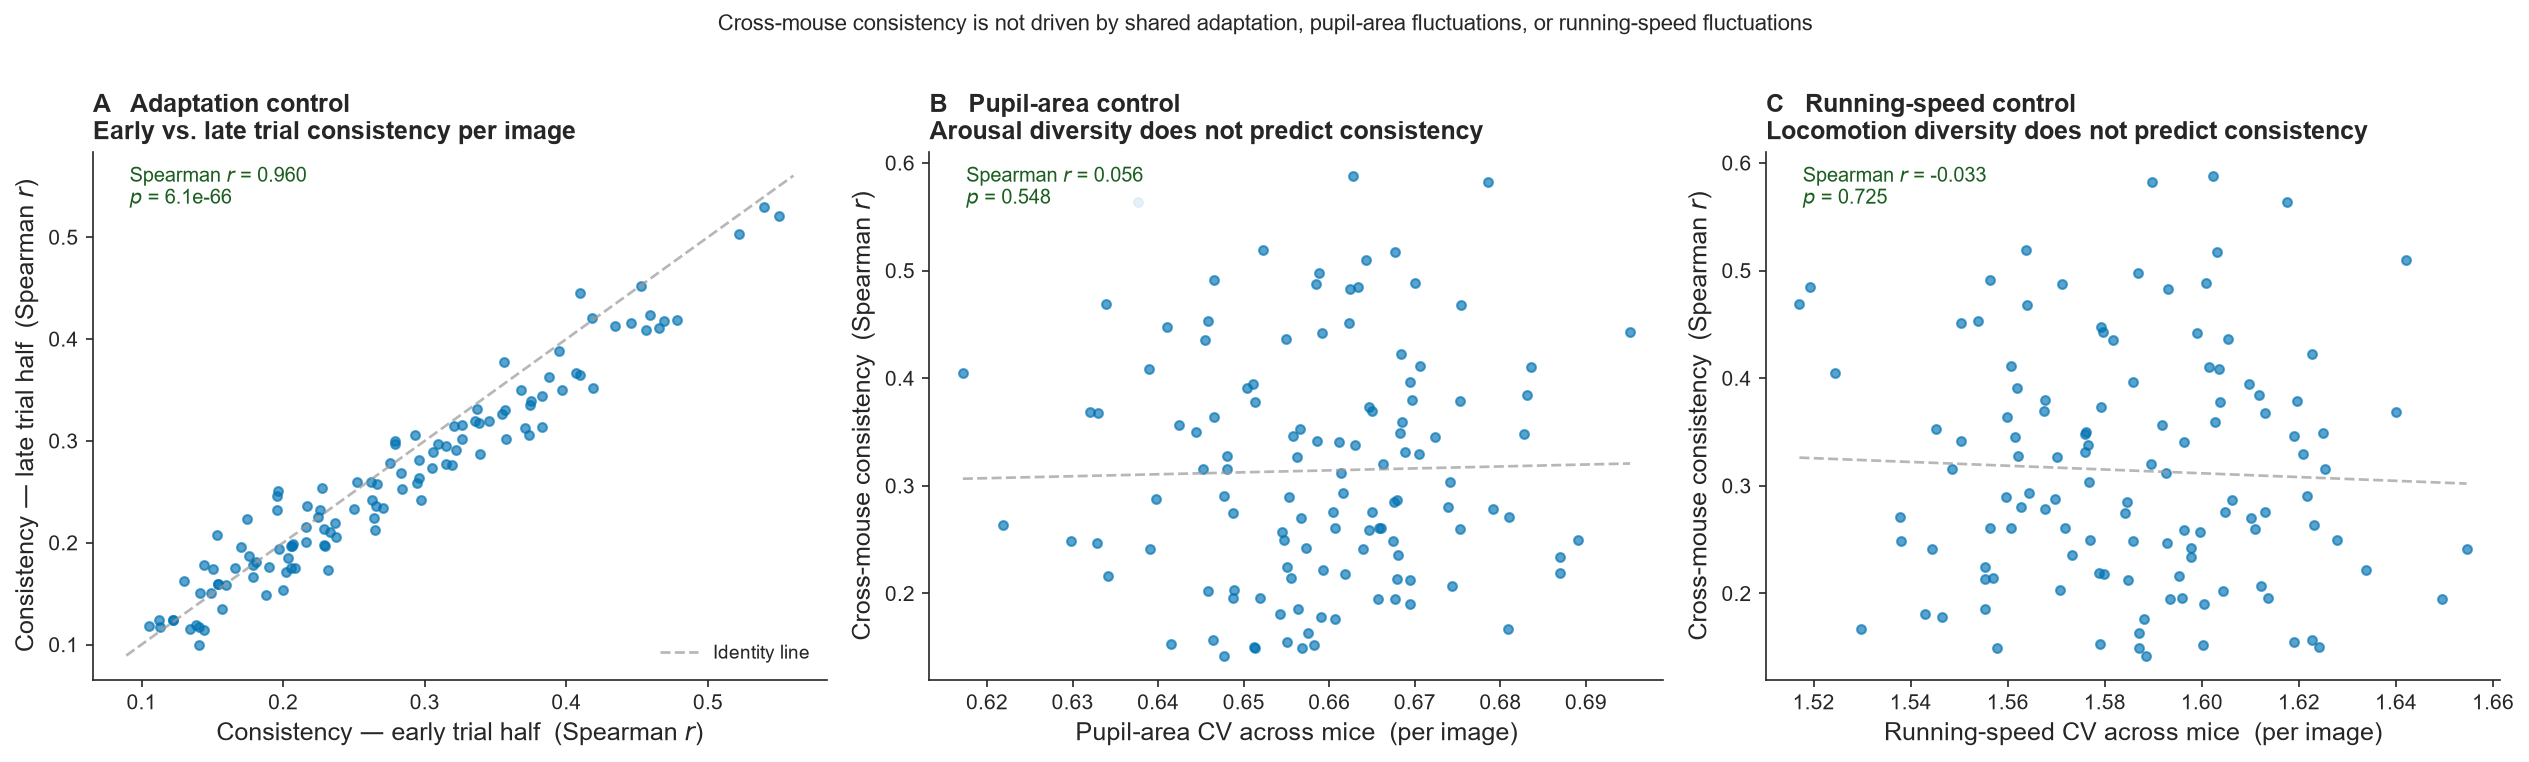

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ── Panel A: early vs. late per-image consistency ────────────────────────────
ax = axes[0]
vmin = min(c_early.min(), c_late.min()) - 0.01
vmax = max(c_early.max(), c_late.max()) + 0.01
ax.scatter(c_early, c_late, s=18, color=COL_DATA, alpha=0.65, rasterized=True)
ax.plot([vmin, vmax], [vmin, vmax], color=COL_REF, linestyle='--',
        linewidth=1.3, alpha=0.7, label='Identity line')
ax.annotate(f'Spearman $r$ = {r_adapt:.3f}\n$p$ = {p_adapt:.1e}',
            xy=(0.05, 0.90), xycoords='axes fraction',
            fontsize=9.5, color=COL_FIT,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85))
ax.set_xlabel('Consistency — early trial half  (Spearman $r$)')
ax.set_ylabel('Consistency — late trial half  (Spearman $r$)')
ax.set_title('A   Adaptation control\n'
             'Early vs. late trial consistency per image',
             loc='left', fontweight='bold', pad=6)
ax.legend(frameon=False, fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

# ── Panel B: pupil CV vs. consistency ────────────────────────────────────────
ax = axes[1]
ax.scatter(pupil_cv[valid_p], consistency_per_image[valid_p],
           s=18, color=COL_DATA, alpha=0.65, rasterized=True)

# Reference regression line
m_p, b_p = np.polyfit(pupil_cv[valid_p], consistency_per_image[valid_p], 1)
x_p = np.linspace(pupil_cv[valid_p].min(), pupil_cv[valid_p].max(), 100)
ax.plot(x_p, m_p * x_p + b_p, color=COL_REF, linestyle='--',
        linewidth=1.3, alpha=0.7)
ax.annotate(f'Spearman $r$ = {r_pupil:.3f}\n$p$ = {p_pupil:.3f}',
            xy=(0.05, 0.90), xycoords='axes fraction',
            fontsize=9.5, color=COL_FIT,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85))
ax.set_xlabel('Pupil-area CV across mice  (per image)')
ax.set_ylabel('Cross-mouse consistency  (Spearman $r$)')
ax.set_title('B   Pupil-area control\n'
             'Arousal diversity does not predict consistency',
             loc='left', fontweight='bold', pad=6)
ax.spines[['top', 'right']].set_visible(False)

# ── Panel C: running CV vs. consistency ──────────────────────────────────────
ax = axes[2]
ax.scatter(run_cv[valid_r], consistency_per_image[valid_r],
           s=18, color=COL_DATA, alpha=0.65, rasterized=True)

m_r, b_r = np.polyfit(run_cv[valid_r], consistency_per_image[valid_r], 1)
x_r = np.linspace(run_cv[valid_r].min(), run_cv[valid_r].max(), 100)
ax.plot(x_r, m_r * x_r + b_r, color=COL_REF, linestyle='--',
        linewidth=1.3, alpha=0.7)
ax.annotate(f'Spearman $r$ = {r_run:.3f}\n$p$ = {p_run:.3f}',
            xy=(0.05, 0.90), xycoords='axes fraction',
            fontsize=9.5, color=COL_FIT,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85))
ax.set_xlabel('Running-speed CV across mice  (per image)')
ax.set_ylabel('Cross-mouse consistency  (Spearman $r$)')
ax.set_title('C   Running-speed control\n'
             'Locomotion diversity does not predict consistency',
             loc='left', fontweight='bold', pad=6)
ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Cross-mouse consistency is not driven by shared adaptation, '
             'pupil-area fluctuations, or running-speed fluctuations',
             fontsize=10.5, y=1.01)

print_figure_data(
    'Fig. 7A — Adaptation control: early vs. late trial consistency per image',
    consistency_early_half=c_early,
    consistency_late_half=c_late,
    spearman_r_early_vs_late=r_adapt,
    spearman_p_early_vs_late=p_adapt,
)
print_figure_data(
    'Fig. 7B — Pupil-area control: pupil-area CV vs. cross-mouse consistency',
    pupil_cv_valid_images=pupil_cv[valid_p],
    consistency_valid_images=consistency_per_image[valid_p],
    regression_slope=m_p,
    regression_intercept=b_p,
    spearman_r_pupil_cv_vs_consistency=r_pupil,
    spearman_p_pupil_cv_vs_consistency=p_pupil,
)
print_figure_data(
    'Fig. 7C — Running-speed control: running-speed CV vs. cross-mouse consistency',
    running_cv_valid_images=run_cv[valid_r],
    consistency_valid_images=consistency_per_image[valid_r],
    regression_slope=m_r,
    regression_intercept=b_r,
    spearman_r_running_cv_vs_consistency=r_run,
    spearman_p_running_cv_vs_consistency=p_run,
)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig7_controls.png', bbox_inches='tight')
plt.show()


Fig. S10A — Distribution of early−late consistency differences per image

--- early_minus_late_delta ---
shape=(118,)
[ 0.03882   0.023281  0.002308  0.018434 -0.035493  0.005465  0.03668  -0.002088 -0.018822  0.039635  0.022915  0.008554  0.052174 -0.007077 -0.00545   0.005862  0.016432  0.006937  0.03233
  0.051517]
...[118 elements total]

--- mean_delta ---
0.015302289031432957

--- ttest_p_delta_vs_zero ---
1.1216504192127316e-08

Fig. S10B — Early-half consistency vs. full-session consistency

--- full_session_consistency ---
shape=(118,)
[0.422874 0.150347 0.320186 0.409948 0.482925 0.359236 0.40502  0.163267 0.260908 0.19579  0.275605 0.248535 0.290777 0.303716 0.260574 0.379713 0.378248 0.45102  0.32783  0.369047]
...[118 elements total]

--- early_half_consistency ---
shape=(118,)
[0.374009 0.140579 0.261737 0.368076 0.409528 0.32051  0.375335 0.122165 0.216978 0.188181 0.233129 0.207071 0.265008 0.25242  0.226296 0.336903 0.33582  0.395129 0.296116 0.338711]
...[118 element

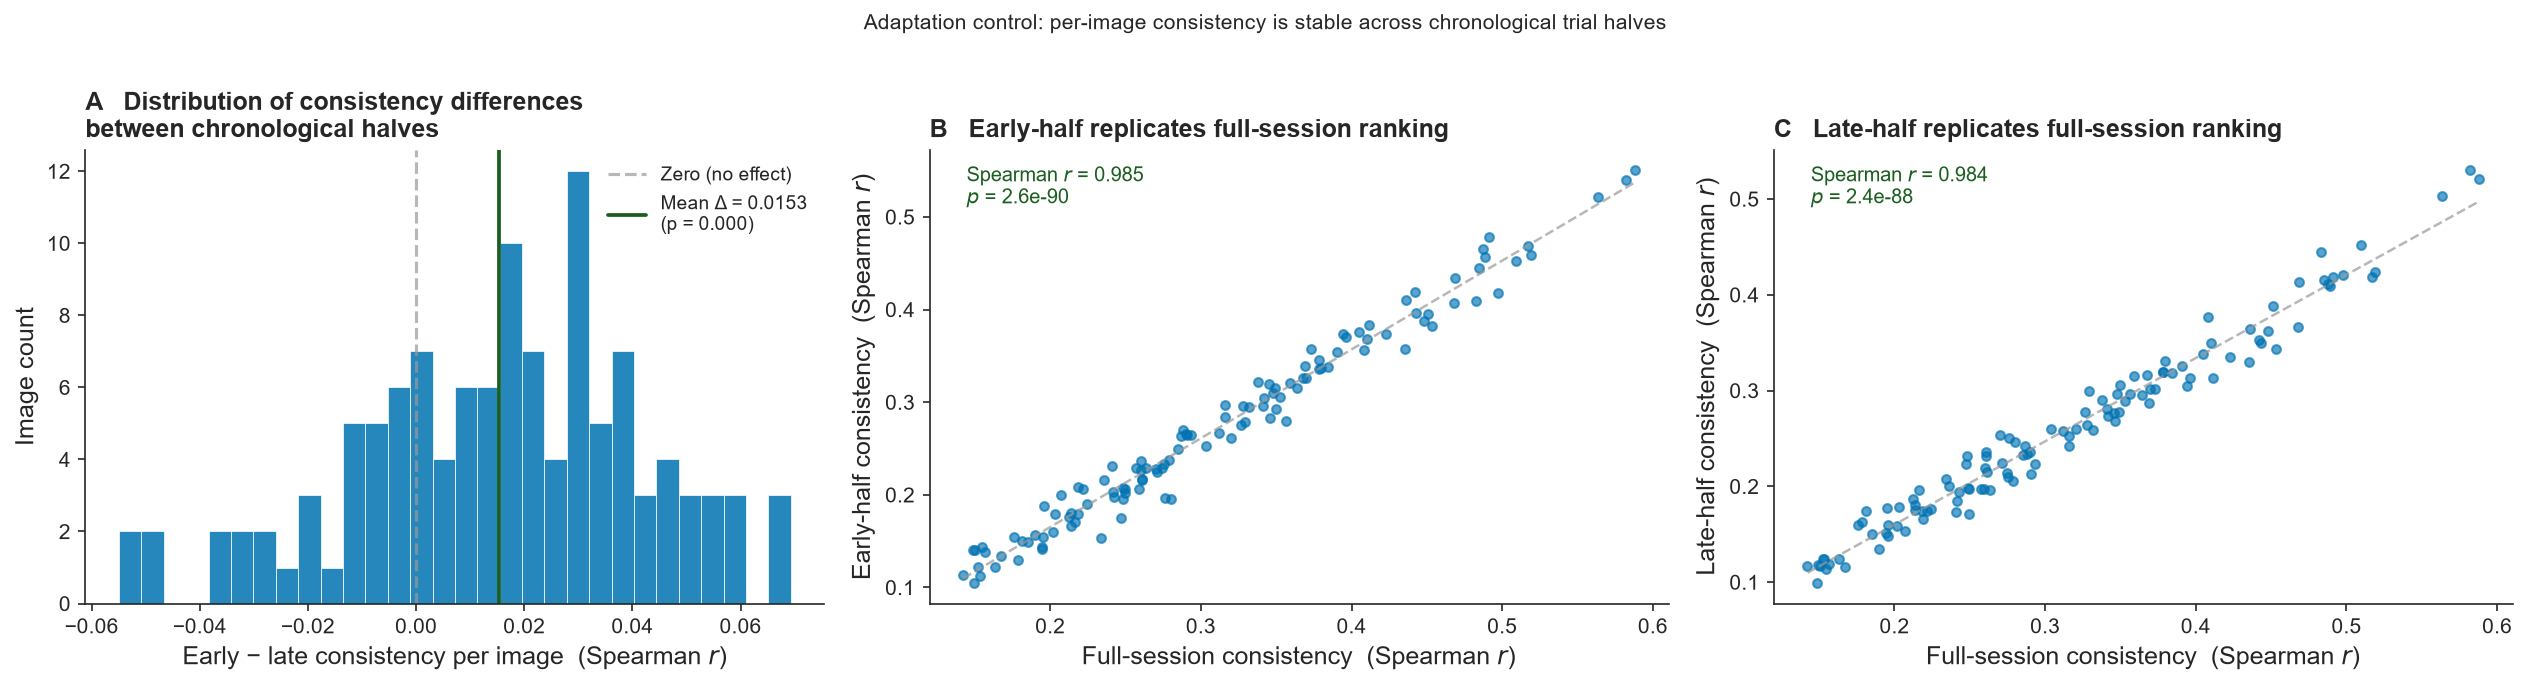

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

# ── Panel A: histogram of per-image early − late differences ─────────────────
ax = axes[0]
ax.hist(delta_c, bins=30, color=COL_DATA, alpha=0.85,
        edgecolor='white', linewidth=0.4)
ax.axvline(0, color=COL_REF, linestyle='--', linewidth=1.5, alpha=0.7,
           label='Zero (no effect)')
ax.axvline(delta_c.mean(), color=COL_FIT, linestyle='-', linewidth=1.8,
           label=f'Mean Δ = {delta_c.mean():.4f}\n(p = {p_delta:.3f})')
ax.set_xlabel('Early − late consistency per image  (Spearman $r$)')
ax.set_ylabel('Image count')
ax.set_title('A   Distribution of consistency differences\n'
             'between chronological halves',
             loc='left', fontweight='bold', pad=6)
ax.legend(frameon=False, fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

# ── Panel B: early-half consistency vs. full-session consistency ──────────────
ax = axes[1]
ax.scatter(consistency_per_image, c_early, s=18,
           color=COL_DATA, alpha=0.65, rasterized=True)
r_ef, p_ef = spearmanr(consistency_per_image, c_early)
m_ef, b_ef = np.polyfit(consistency_per_image, c_early, 1)
x_ef = np.linspace(consistency_per_image.min(), consistency_per_image.max(), 100)
ax.plot(x_ef, m_ef * x_ef + b_ef, color=COL_REF, linestyle='--',
        linewidth=1.2, alpha=0.7)
ax.annotate(f'Spearman $r$ = {r_ef:.3f}\n$p$ = {p_ef:.1e}',
            xy=(0.05, 0.88), xycoords='axes fraction',
            fontsize=9.5, color=COL_FIT,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85))
ax.set_xlabel('Full-session consistency  (Spearman $r$)')
ax.set_ylabel('Early-half consistency  (Spearman $r$)')
ax.set_title('B   Early-half replicates full-session ranking',
             loc='left', fontweight='bold', pad=6)
ax.spines[['top', 'right']].set_visible(False)

# ── Panel C: late-half consistency vs. full-session consistency ───────────────
ax = axes[2]
ax.scatter(consistency_per_image, c_late, s=18,
           color=COL_DATA, alpha=0.65, rasterized=True)
r_lf, p_lf = spearmanr(consistency_per_image, c_late)
m_lf, b_lf = np.polyfit(consistency_per_image, c_late, 1)
x_lf = np.linspace(consistency_per_image.min(), consistency_per_image.max(), 100)
ax.plot(x_lf, m_lf * x_lf + b_lf, color=COL_REF, linestyle='--',
        linewidth=1.2, alpha=0.7)
ax.annotate(f'Spearman $r$ = {r_lf:.3f}\n$p$ = {p_lf:.1e}',
            xy=(0.05, 0.88), xycoords='axes fraction',
            fontsize=9.5, color=COL_FIT,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85))
ax.set_xlabel('Full-session consistency  (Spearman $r$)')
ax.set_ylabel('Late-half consistency  (Spearman $r$)')
ax.set_title('C   Late-half replicates full-session ranking',
             loc='left', fontweight='bold', pad=6)
ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Adaptation control: per-image consistency is stable '
             'across chronological trial halves',
             fontsize=10, y=1.01)

print_figure_data(
    'Fig. S10A — Distribution of early−late consistency differences per image',
    early_minus_late_delta=delta_c,
    mean_delta=delta_c.mean(),
    ttest_p_delta_vs_zero=p_delta,
)
print_figure_data(
    'Fig. S10B — Early-half consistency vs. full-session consistency',
    full_session_consistency=consistency_per_image,
    early_half_consistency=c_early,
    regression_slope=m_ef,
    regression_intercept=b_ef,
    spearman_r_early_vs_full=r_ef,
    spearman_p_early_vs_full=p_ef,
)
print_figure_data(
    'Fig. S10C — Late-half consistency vs. full-session consistency',
    full_session_consistency=consistency_per_image,
    late_half_consistency=c_late,
    regression_slope=m_lf,
    regression_intercept=b_lf,
    spearman_r_late_vs_full=r_lf,
    spearman_p_late_vs_full=p_lf,
)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'figS10_adaptation_control.png', bbox_inches='tight')
plt.show()